## Equipo_1 - Competencia Kaggle

### Sergio Ballesteros SUares - sa.ballesteros@uniandes.edu.co
# Proyecto ARTEMIS — RAG + Tool Calling
**Curso:** Modelos Avanzados de Procesamiento de Lenguaje Natural  

| Componente | Modelo | Técnica |
|---|---|---|
| Encoder | BAAI/bge-small-en-v1.5 | Fine-tuning con MNRL + hard negatives |
| Índice | FAISS IndexFlatIP | Dense + BM25 híbrido (RRF) |
| Decoder | meta-llama/Llama-3.2-1B-Instruct | QLoRA 4-bit, SFT response-only |
| Post-proc | regex + reordering | Canonicalización estricta |

### 1.0 Persistencia en Google Colab

Monta Google Drive y cambia el directorio de trabajo al proyecto en Drive.
Con , las sesiones posteriores saltan las etapas ya completadas.
En entorno local esta celda no hace nada.

In [4]:
import os, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_DIR = "/content/drive/MyDrive/artemis"
    os.makedirs(DRIVE_DIR, exist_ok=True)
    os.chdir(DRIVE_DIR)
    sys.path.insert(0, "scripts")
    print(f"Colab: working from {os.getcwd()}")
else:
    print("Local environment")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab: working from /content/drive/MyDrive/artemis


## 1. Entorno y Dependencias

Instalamos las dependencias del proyecto desde `requirements.txt` e importamos las bibliotecas clave.
El flag `FORCE_RECOMPUTE` controla si las etapas cacheadas (chunking, índice, fine-tuning) se vuelven a ejecutar desde cero o se cargan desde disco.

In [5]:
# Instalar dependencias
!pip install -r requirements.txt
print('Dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
Dependencies installed


In [6]:
import os, sys, json, re
import pandas as pd
import numpy as np
import torch
import faiss
import yaml
from pathlib import Path
from tqdm import tqdm
from rank_bm25 import BM25Okapi

# Make scripts importable
sys.path.insert(0, 'scripts')
from utils import load_tools_def, enrich_tools_def, canonicalize, load_hf_token, load_kaggle_token

print(f'PyTorch: {torch.__version__} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

FORCE_RECOMPUTE = True


PyTorch: 2.10.0+cu128 | GPU: Tesla T4


### 1.1 Autenticación

Cargamos los tokens de Hugging Face, NVIDIA build y Kaggle desde el archivo `.env` local.
El token de HF es necesario para descargar `BAAI/bge-small-en-v1.5` y `meta-llama/Llama-3.2-1B-Instruct`.
El token de Kaggle permite descargar los archivos de la competencia.
El token de Nvidia permite acceder al modelo `meta/llama-3_1-8b-instruct` para la creacion de registros sinteticos.

In [7]:
# Autenticación — ambos tokens leídos desde .env
load_hf_token()
print('HF authentication OK')

load_kaggle_token()
print('Kaggle authentication OK')

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF authentication OK
Kaggle authentication OK


### 1.2 Descarga de Datos

Descargamos los archivos de la competencia con `kagglehub` y los copiamos a `raw_data/`.
Si la carpeta ya existe y `FORCE_RECOMPUTE=False` la descarga se omite.

| Archivo | Rol en el pipeline |
|---|---|
| `train.csv` | 2718 ejemplos `(query, tool_call)` para entrenar el decoder |
| `test.csv` | 766 queries para predecir (submission) |
| `consultas_centro_control.json` | 810 pares `(query, doc_id)` para fine-tuning del encoder |
| `knowledge_base/` | 54 documentos técnicos MASA en Markdown — corpus de retrieval |
| `tools_definition.json` | Definición canónica de las 10 herramientas con todos los valores válidos |

In [8]:
import kagglehub
import shutil

COMPETITION = 'competencia-mapln-artemis-asistente-rag-estacion-espacial-202610'

RAW_DATA = Path('raw_data')
RAW_DATA.mkdir(exist_ok=True)

if FORCE_RECOMPUTE or not any(RAW_DATA.iterdir()):
    _src = Path(kagglehub.competition_download(COMPETITION))
    for item in _src.iterdir():
        dst = RAW_DATA / item.name
        if item.is_dir():
            shutil.copytree(item, dst, dirs_exist_ok=True)
        else:
            shutil.copy2(item, dst)

DATA_DIR = RAW_DATA
print(f'Datos en: {DATA_DIR}')
print(sorted(p.name for p in DATA_DIR.iterdir()))

100%|██████████| 346k/346k [00:00<00:00, 419kB/s]

Extracting files...


Datos en: raw_data
['consultas_centro_control.json', 'knowledge_base', 'sample_submission.csv', 'test.csv', 'tools_definition.json', 'train.csv']


## 2. Carga y Exploración de Datos

Cargamos los tres artefactos principales y realizamos un análisis exploratorio:
- **Distribución de herramientas**: `activate_protocol` y `send_alert` concentran >57% de los ejemplos → el dataset está desbalanceado.
- **Duplicados**: el enunciado advierte que `train.csv` contiene ruido; los eliminamos en la sección de preprocesamiento.
- **Longitud de queries**: media ~18 palabras; ninguna supera el contexto del modelo.

In [9]:
# Carga de train.csv, consultas_centro_control.json, documentos MASA
train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df  = pd.read_csv(DATA_DIR / 'test.csv')

with open(DATA_DIR / 'consultas_centro_control.json') as f:
    consultas = json.load(f)

# Normalize tools_def from list format and enrich with all training values.
# tools_definition.json only lists ~3 example values per parameter; the full
# set comes from training data (e.g. 18 protocol IDs, 6 modules, etc.)
tools_def = load_tools_def(str(DATA_DIR / 'tools_definition.json'))
enrich_tools_def(tools_def, str(DATA_DIR / 'train.csv'))

DOCS_DIR = DATA_DIR / 'knowledge_base' / 'knowledge_base'
docs = {}
for doc_dir in sorted(DOCS_DIR.iterdir()):
    if doc_dir.is_dir():
        md = doc_dir / 'doc.md'
        if md.exists():
            docs[doc_dir.name] = md.read_text(encoding='utf-8')

print(f'Train: {len(train_df)} | Test: {len(test_df)} | Docs: {len(docs)} | Consultas: {len(consultas)}')
# Verify tools_def is properly structured (spot check)
print(f'Tools loaded: {list(tools_def.keys())}')
print(f'activate_protocol.protocol_id values: {tools_def["activate_protocol"]["parameters"]["protocol_id"]["values"]}')

Train: 2718 | Test: 766 | Docs: 54 | Consultas: 810
Tools loaded: ['get_telemetry', 'get_crew_status', 'get_module_status', 'send_alert', 'send_message', 'schedule_maintenance', 'activate_protocol', 'control_system', 'calculate_trajectory', 'request_supply', 'no_action']
activate_protocol.protocol_id values: ['MASA-SEC-001', 'MASA-SEC-002', 'MASA-SEC-003', 'MASA-SEC-004', 'MASA-SEC-005', 'MASA-SEC-006', 'MASA-SEC-007', 'MASA-SEC-008', 'MASA-SEC-009', 'MASA-SEC-010', 'MASA-SEC-011', 'MASA-SEC-012', 'MASA-SEC-013', 'MASA-SEC-014', 'MASA-SEC-015', 'MASA-SEC-016', 'MASA-SEC-017', 'MASA-SEC-018', 'MASA-SEC-019', 'MASA-SEC-020']


In [10]:
# Análisis exploratorio: distribución de tools, duplicados, estadísticas
tool_names = train_df['tool_call'].str.extract(r'^(\w+)')[0]
print('=== Distribución de tools ===')
print(tool_names.value_counts().to_string())

print(f'\nDuplicados exactos (query+tool): {train_df.duplicated(["query","tool_call"]).sum()}')
print(f'Queries con etiquetas conflictivas: {train_df.duplicated("query").sum()}')

query_lens = train_df['query'].str.split().str.len()
print(f'\nLongitud query — media: {query_lens.mean():.1f}, max: {query_lens.max()}, min: {query_lens.min()}')
print(f'Tool calls únicos: {train_df["tool_call"].nunique()}')

# Consultas sin hard_negative
with_neg = sum(1 for c in consultas if c.get('hard_negative_doc_id'))
print(f'\nConsultas con hard_negative: {with_neg}/{len(consultas)}')

=== Distribución de tools ===
0
activate_protocol       797
send_alert              675
no_action               331
control_system          162
calculate_trajectory    121
request_supply          121
schedule_maintenance    117
get_telemetry           107
get_module_status       104
get_crew_status          93
send_message             90

Duplicados exactos (query+tool): 148
Queries con etiquetas conflictivas: 148

Longitud query — media: 18.8, max: 34, min: 6
Tool calls únicos: 441

Consultas con hard_negative: 622/810


### 2.1 Distribución Original de Herramientas

La gráfica muestra el desbalance entre clases antes de cualquier augmentación.
Las clases con menos de 100 ejemplos (`send_message`, `get_crew_status`, `get_telemetry`)
son las que más se beneficiarán de la generación sintética.

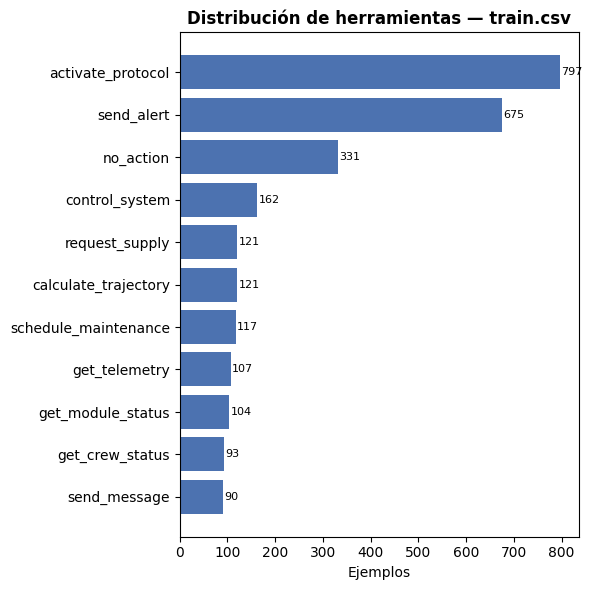

In [11]:
from utils import plot_tool_distribution
plot_tool_distribution(train_df)

## 3. Preprocesamiento

El preprocesamiento tiene tres pasos:
1. **Limpieza y split**: eliminamos duplicados exactos, resolvemos etiquetas conflictivas por mayoría de votos, normalizamos al formato canónico y separamos un 10% como conjunto de validación.
2. **Chunking**: dividimos los 54 documentos técnicos en ventanas de 256 tokens con 64 de overlap, preservando fronteras de documento.
3. **Data augmentation**: generamos queries sintéticas para equilibrar la distribución de herramientas usando `meta/llama-3.1-8b-instruct` vía NVIDIA Build.

### 3.1 Limpieza y Split Train / Val

**Pasos de limpieza:**
- `drop_duplicates(["query","tool_call"])`: elimina pares idénticos.
- `groupby("query").agg(most_frequent)`: cuando una misma query tiene etiquetas distintas, conservamos la más frecuente (ruido de anotación).
- `canonicalize(...)`: corrige menores desviaciones de formato en las etiquetas de entrenamiento.
- Split 90/10 estratificado por semilla aleatoria (seed=42).

`df_train` se guarda en `data/train_split.csv` para que el decoder **nunca vea las queries de validación** durante el fine-tuning (evita data leakage).

In [12]:
df = train_df.drop_duplicates(subset=['query', 'tool_call']).copy()
df_clean = (
    df.groupby('query')['tool_call']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
)
df_clean.columns = ['query', 'tool_call']
df_clean['tool_call'] = df_clean['tool_call'].apply(lambda x: canonicalize(x, tools_def))

val_size = int(len(df_clean) * 0.10)
df_val   = df_clean.sample(val_size, random_state=42)
df_train = df_clean.drop(df_val.index).reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

print(f'Originales: {len(train_df)} → Limpios: {len(df_clean)}')
print(f'Train: {len(df_train)} | Val: {len(df_val)}')

TRAIN_SPLIT_CSV = 'data/train_split.csv'
Path('data').mkdir(exist_ok=True)
df_train.to_csv(TRAIN_SPLIT_CSV, index=False)
print(f'df_train guardado en {TRAIN_SPLIT_CSV}')

Originales: 2718 → Limpios: 2570
Train: 2313 | Val: 257
df_train guardado en data/train_split.csv


### 3.2 Chunking de Documentos MASA

**Estrategia — sliding window a nivel de tokens (state of the art para docs técnicos):**
- Ventana de **256 tokens** con **64 de overlap** (25%): balance entre granularidad y contexto.
- Tokenizador de `BAAI/bge-small-en-v1.5` para respetar el vocabulario del encoder.
- El overlap garantiza que ninguna oración quede cortada entre dos chunks sin contexto.
- Cada chunk se etiqueta con `doc_id` y `chunk_id` para rastrear la proveniencia.

El resultado se guarda en `chunks.json` — entrada directa para el encoder y el índice FAISS.

In [13]:
# Chunking de documentos MASA (256 tokens, 64 overlap)
from chunker import build_chunks

if FORCE_RECOMPUTE or not Path('chunks.json').exists():
    chunks = build_chunks(docs_dir=str(DOCS_DIR), output='chunks.json')
else:
    with open('chunks.json') as f:
        chunks = json.load(f)
    print(f'chunks.json cargado: {len(chunks)} chunks')

doc_counts = {}
for c in chunks:
    doc_counts[c['doc_id']] = doc_counts.get(c['doc_id'], 0) + 1
print(f'Docs chunkeados: {len(doc_counts)} | Chunks/doc promedio: {len(chunks)/len(doc_counts):.1f}')

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Loaded 54 documents
Created 535 chunks → chunks.json
Docs chunkeados: 54 | Chunks/doc promedio: 9.9


### 3.3 Generación de Datos Sintéticos (Data Augmentation)

El conjunto de entrenamiento está desbalanceado: `activate_protocol` y `send_alert` concentran el 57% de los ejemplos, mientras que clases como `send_message` (82), `calculate_trajectory` (80) y `get_crew_status` (77) tienen menos de 100 ejemplos.

**Estrategia — Label-first generation (Wei et al. Self-Instruct, 2022):**
1. Fijamos la `tool_call` canónica exacta que queremos (enumerando todas las combinaciones válidas de parámetros).
2. Mostramos 3 ejemplos reales del entrenamiento como *few-shot seeds*.
3. Le pedimos al LLM que genere una nueva consulta de operador que requiera exactamente esa `tool_call`.
4. Validamos longitud y deduplicamos contra los datos existentes.

Este enfoque garantiza etiquetas 100% correctas (no hay alucinación de la `tool_call` porque ya está fijada).

**Modelo:** `meta/llama-3.1-8b-instruct` vía NVIDIA Build (endpoint gratuito)
- **Licencia:** Meta Llama 3.1 Community License — permite uso académico/investigación.
- **Motivación:** capacidad de seguimiento de instrucciones suficiente para generación de queries cortas; tier gratuito en `build.nvidia.com/models`; API compatible con OpenAI; sin retención de datos según política de NVIDIA.
- **Referencia:** Wei et al. *Self-Instruct* (2022), Gunasekar et al. *Textbooks Are All You Need* (2023).

**API key:** `NVIDIA_API_KEY` en `.env`. El archivo `synthetic_train.csv` se almacena en caché — si ya existe no se re-genera.

In [14]:
from augment_data import augment as augment_data

SYNTHETIC_DIR = Path('data/synthetic')
SYNTHETIC_DIR.mkdir(parents=True, exist_ok=True)
SYNTHETIC_CSV = str(SYNTHETIC_DIR / 'synthetic_train.csv')

if FORCE_RECOMPUTE or not Path(SYNTHETIC_CSV).exists():
    print('Generando datos sintéticos con NVIDIA Build (meta/llama-3.1-8b-instruct)...')
    print('Esto puede tardar ~30 min dependiendo del rate limit de la API.')
    synthetic_df = augment_data(
        train_csv=str(DATA_DIR / 'train.csv'),
        tools_def_file=str(DATA_DIR / 'tools_definition.json'),
        output_csv=SYNTHETIC_CSV,
        target_per_class=350,
        seed=42,
    )
else:
    synthetic_df = pd.read_csv(SYNTHETIC_CSV)
    print(f'synthetic_train.csv ya existe en {SYNTHETIC_CSV}: {len(synthetic_df)} filas (caché)')

# Distribución combinada
combined = pd.concat([
    train_df[['query', 'tool_call']],
    synthetic_df[['query', 'tool_call']],
], ignore_index=True).drop_duplicates(subset=['query'])

combined_counts = combined['tool_call'].str.extract(r'^(\w+)')[0].value_counts()
print(f'\nDistribución combinada (train + sintéticos): {len(combined)} ejemplos')
print(combined_counts.to_string())

Generando datos sintéticos con NVIDIA Build (meta/llama-3.1-8b-instruct)...
Esto puede tardar ~30 min dependiendo del rate limit de la API.
Augmentation targets (TARGET_PER_CLASS=350)
  get_telemetry               107 → +243
  get_crew_status              77 → +273
  get_module_status           102 → +248
  send_alert                  662 → +0
  send_message                 82 → +268
  schedule_maintenance        117 → +233
  activate_protocol           771 → +0
  control_system              162 → +188
  calculate_trajectory         80 → +270
  request_supply              114 → +236

[get_telemetry] generating 243 examples...


  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 4

  50/243


  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 4

  100/243


...

    [82/97] control_system(module='tucan',system='ventilation',action='d → 5/5
    [83/97] control_system(module='tucan',system='ventilation',action='i → 5/5
    [84/97] control_system(module='tucan',system='ventilation',action='d → 5/5
    [85/97] control_system(module='tucan',system='heating',action='deact → 5/5
    [86/97] control_system(module='tucan',system='heating',action='incre → 5/5
    [87/97] control_system(module='tucan',system='heating',action='decre → 5/5


  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 4

    [88/97] control_system(module='tucan',system='lighting',action='acti → 5/5
    [89/97] control_system(module='tucan',system='lighting',action='incr → 5/5
    [90/97] control_system(module='tucan',system='lighting',action='decr → 5/5
    [91/97] control_system(module='tucan',system='cooling',action='activ → 5/5
    [92/97] control_system(module='tucan',system='cooling',action='deact → 5/5
    [93/97] control_system(module='tucan',system='cooling',action='decre → 5/5
    [94/97] control_system(module='tucan',system='filtration',action='ac → 5/5


  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 429, 'title': 'Too Many Requests'}
  [API error] RateLimitError: Error code: 429 - {'status': 4

    [95/97] control_system(module='tucan',system='filtration',action='de → 5/5
    [96/97] control_system(module='tucan',system='filtration',action='in → 5/5
    [97/97] control_system(module='tucan',system='filtration',action='de → 5/5

Saved 4064 synthetic rows → data/synthetic/synthetic_train.csv

Distribución combinada (train + sintéticos): 6634 ejemplos
0
send_alert              1332
get_telemetry           1000
activate_protocol        891
control_system           835
schedule_maintenance     530
calculate_trajectory     350
get_crew_status          350
get_module_status        350
send_message             350
request_supply           350
no_action                296


### 3.4 Distribución con Datos Sintéticos

La gráfica compara la distribución antes y después de la augmentación.
El segundo pass de *zero-coverage fill* garantiza al menos 5 ejemplos por cada combinación única de herramienta + parámetros, cubriendo `MASA-SEC-016` y `MASA-SEC-020` que no aparecen en `train.csv`.

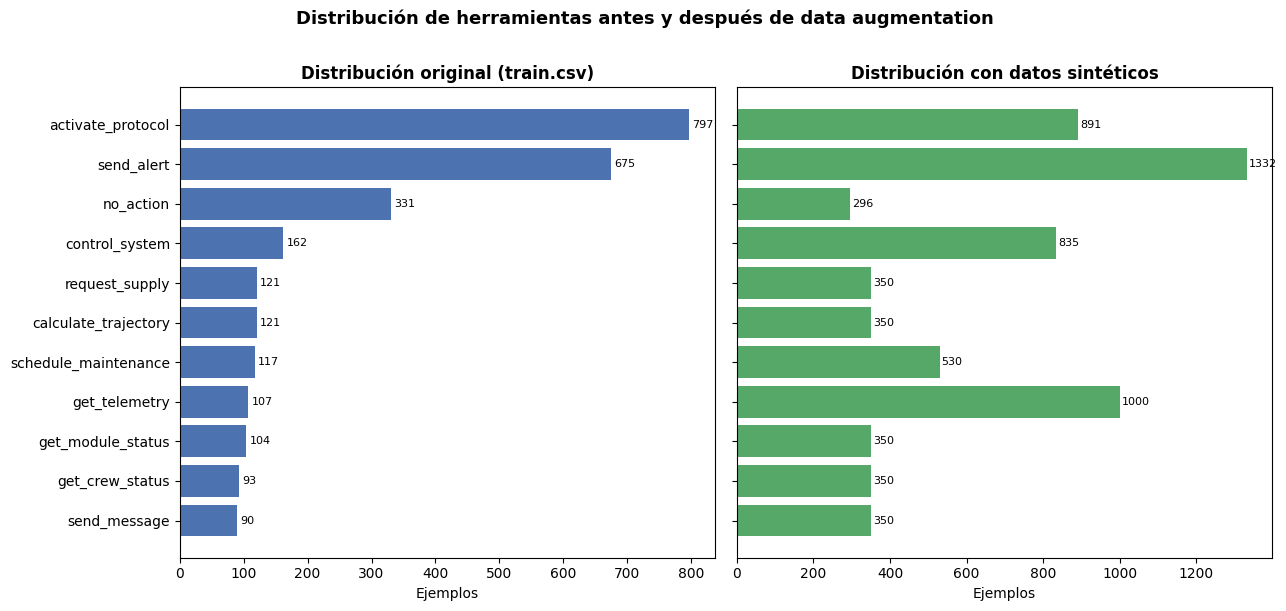

In [15]:
plot_tool_distribution(train_df, combined)

## 4. Fine-tuning del Encoder

Ajustamos `BAAI/bge-small-en-v1.5` con **MultipleNegativesRankingLoss** (InfoNCE-style) sobre el conjunto de consultas históricas del centro de control.

**Decisiones de diseño:**
| Elemento | Opción elegida | Alternativas descartadas |
|---|---|---|
| Arquitectura | BGE-small (33M params) | BGE-large (excede VRAM en fine-tuning) |
| Loss | MNRL (InfoNCE) | TripletLoss (requiere triplets explícitos para todos) |
| Positivos | Chunk con mayor overlap de tokens | Chunk 0 siempre (sesgado hacia encabezados) |
| Hard negatives | `hard_negative_doc_id` de las consultas | Solo negatives en batch |
| Evaluación | InformationRetrievalEvaluator Recall@k | Sin evaluador (save_best_model aleatorio) |

El evaluador usa el 20% de las consultas como hold-out y permite que `save_best_model=True` guarde el checkpoint con mejor recall, no simplemente el último.

In [16]:
# Fine-tuning de BAAI/bge-small-en-v1.5 con MNRL + hard negatives
# Ref: Wang et al. 'Text Embeddings by Weakly-Supervised Contrastive Pre-training' (2022)

ENCODER_DIR = 'models/encoder'

if FORCE_RECOMPUTE or not (Path(ENCODER_DIR) / 'config.json').exists():
    print('Fine-tuning encoder...')
    from finetune_encoder import finetune_encoder
    finetune_encoder(
        chunks_file='chunks.json',
        consultas_file=str(DATA_DIR / 'consultas_centro_control.json'),
        output_dir=ENCODER_DIR,
    )
else:
    print(f'Encoder fine-tuneado encontrado en {ENCODER_DIR}')

Fine-tuning encoder...


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading chunks...
Consultas — train: 648 | eval: 162
Building training examples...
  648 examples (497 with hard negatives)
Building IR evaluator...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Encoder saved → models/encoder


### 4.1 Métricas del Encoder durante Entrenamiento

La curva muestra el Recall@k del evaluador IR en el conjunto hold-out después de cada epoch.
Un recall@1 alto indica que el chunk más relevante aparece en el primer resultado — crítico para que el decoder reciba contexto útil.

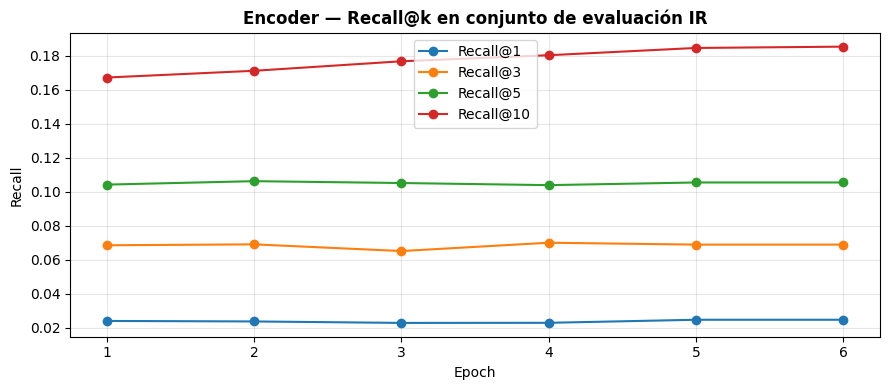

In [17]:
from utils import plot_encoder_metrics
plot_encoder_metrics(ENCODER_DIR)

## 5. Índice de Recuperación (FAISS + BM25)

Construimos el índice en dos pasos:
1. **Codificación**: cada chunk se convierte en un vector de 384 dimensiones con el encoder fine-tuneado. Los vectores se normalizan (L2) para que el producto interno equivalga a similitud coseno.
2. **Índice FAISS `IndexFlatIP`**: búsqueda exacta por producto interno — adecuada para el tamaño de corpus (≤ 10k chunks) sin sacrificio de recall.
3. **Índice BM25**: complementa la búsqueda densa con señales léxicas — especialmente útil para queries con términos técnicos exactos (e.g. `MASA-SEC-012`).

El índice completo se serializa en `retrieval_index.json` (formato exigido por el enunciado).

In [18]:
# Codificar chunks con encoder fine-tuneado y construir índice FAISS
# Ref: Johnson et al. 'Billion-scale similarity search with GPUs' (2021)

from sentence_transformers import SentenceTransformer

RETRIEVAL_INDEX = 'retrieval_index.json'
QUERY_PREFIX = 'Represent this sentence for searching relevant passages: '

if FORCE_RECOMPUTE or not Path(RETRIEVAL_INDEX).exists():
    print('Codificando chunks con encoder...')
    encoder = SentenceTransformer(ENCODER_DIR)
    chunk_texts = [c['text'] for c in chunks]

    # Codificar en batches (sin prefix para documentos — BGE style)
    chunk_vectors = encoder.encode(
        chunk_texts,
        batch_size=128,
        normalize_embeddings=True,
        show_progress_bar=True,
    ).astype(np.float32)

    # Construir retrieval_index.json (formato requerido por el entregable)
    retrieval_index = []
    for i, c in enumerate(chunks):
        retrieval_index.append({
            'doc_id':   c['doc_id'],
            'chunk_id': c['chunk_id'],
            'text':     c['text'],
            'vector':   chunk_vectors[i].tolist(),
        })

    with open(RETRIEVAL_INDEX, 'w', encoding='utf-8') as f:
        json.dump(retrieval_index, f, ensure_ascii=False)
    print(f'retrieval_index.json guardado: {len(retrieval_index)} entradas')

    del encoder
    torch.cuda.empty_cache()
else:
    print(f'{RETRIEVAL_INDEX} ya existe, cargando...')
    with open(RETRIEVAL_INDEX) as f:
        retrieval_index = json.load(f)
    chunk_vectors = np.array([e['vector'] for e in retrieval_index], dtype=np.float32)
    print(f'  {len(retrieval_index)} chunks cargados')

Codificando chunks con encoder...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

retrieval_index.json guardado: 535 entradas


In [19]:
# Construir índice FAISS (IndexFlatIP = cosine exacto para vectores normalizados)
faiss.normalize_L2(chunk_vectors)
faiss_index = faiss.IndexFlatIP(chunk_vectors.shape[1])
faiss_index.add(chunk_vectors)
print(f'FAISS IndexFlatIP: {faiss_index.ntotal} vectores, dim={chunk_vectors.shape[1]}')

# Construir índice BM25 para búsqueda híbrida
# Ref: Robertson & Zaragoza 'The Probabilistic Relevance Framework: BM25' (2009)
bm25_corpus = [c['text'].lower().split() for c in retrieval_index]
bm25 = BM25Okapi(bm25_corpus)
print(f'BM25 index: {len(bm25_corpus)} documentos')

FAISS IndexFlatIP: 535 vectores, dim=384
BM25 index: 535 documentos


### 5.1 Recuperación Híbrida con Reciprocal Rank Fusion

**¿Por qué híbrido?**
- El encoder denso captura similitud semántica pero puede fallar en términos OOV o exactos.
- BM25 es robusto ante términos exactos (nombres de protocolos, módulos) pero no entiende semántica.
- **RRF** (Cormack et al. 2009) combina los rankings sin requerir calibración de scores: `score(d) = Σ 1/(k + rank(d))` con k=60.

Este mismo retriever se usa tanto en el **entrenamiento del decoder** como en **inferencia**, eliminando el mismatch train/test.

In [20]:
# Función de recuperación híbrida BM25 + Dense con Reciprocal Rank Fusion
# Ref: Cormack et al. 'Reciprocal Rank Fusion' (SIGIR 2009)

def retrieve_hybrid(query: str, query_emb: np.ndarray, top_k: int = 5, rrf_k: int = 60) -> list[str]:
    n_candidates = top_k * 3

    # Dense retrieval
    _, I_dense = faiss_index.search(query_emb.reshape(1, -1), n_candidates)
    dense_ranks = {int(I_dense[0][i]): i for i in range(len(I_dense[0]))}

    # Sparse BM25 retrieval
    tokens = query.lower().split()
    bm25_scores = np.array(bm25.get_scores(tokens))
    bm25_top = np.argsort(bm25_scores)[::-1][:n_candidates]
    bm25_ranks = {int(idx): rank for rank, idx in enumerate(bm25_top)}

    # Reciprocal Rank Fusion
    all_ids = set(dense_ranks) | set(bm25_ranks)
    rrf_scores = {}
    for idx in all_ids:
        score = 0.0
        if idx in dense_ranks:
            score += 1.0 / (rrf_k + dense_ranks[idx] + 1)
        if idx in bm25_ranks:
            score += 1.0 / (rrf_k + bm25_ranks[idx] + 1)
        rrf_scores[idx] = score

    top_ids = sorted(rrf_scores, key=rrf_scores.get, reverse=True)[:top_k]
    return [retrieval_index[i]['text'] for i in top_ids if i < len(retrieval_index)]


# Prueba de retrieval
from sentence_transformers import SentenceTransformer as ST
_enc_test = ST(ENCODER_DIR)
_emb_test = _enc_test.encode([QUERY_PREFIX + 'oxygen levels are dropping in jaguar'],
                              normalize_embeddings=True)[0].astype(np.float32)
_results  = retrieve_hybrid('oxygen levels are dropping in jaguar', _emb_test, top_k=3)
print(f'Test retrieval: {len(_results)} chunks recuperados')
print(f'  Primer chunk (primeros 200 chars): {_results[0][:200]}...')
del _enc_test

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Test retrieval: 3 chunks recuperados
  Primer chunk (primeros 200 chars): to evacuate immediately while donning portable oxygen masks from the nearest emergency station. systems engineer pavel kozlov coordinates the response from the jaguar module, verifying oxygen flow rat...


### 5.2 Evaluación de Retrieval — Recall@k

**¿Por qué esta métrica es más valiosa que la curva de pérdida?**

El pipeline tiene dos etapas independientes de error:

```
query → [ENCODER] → top-k chunks → [DECODER] → tool_call
```

- Si el Recall@1 del encoder es bajo (< 80%), el decoder recibe contexto equivocado y es imposible predecir la tool call correcta, sin importar qué tan bien entrene el decoder.
- Si el Recall@1 es alto (> 90%), el cuello de botella está en el decoder — ahí hay que optimizar.

**Interpretación:**
| Recall@1 | Diagnóstico |
|---|---|
| < 70% | El encoder es el problema principal |
| 70–85% | Ambos contribuyen; optimizar encoder primero |
| > 85% | El decoder es el cuello de botella |

Comparamos el encoder **base** (`BAAI/bge-small-en-v1.5` sin fine-tuning) con el encoder **fine-tuneado** para cuantificar el beneficio del entrenamiento.

In [21]:
from utils import evaluate_retrieval_recall, plot_retrieval_recall

ENCODER_BASE = 'BAAI/bge-small-en-v1.5'
CONSULTAS_FILE = str(DATA_DIR / 'consultas_centro_control.json')

print('Evaluando encoder base (sin fine-tuning)...')
recall_base = evaluate_retrieval_recall(
    consultas_file=CONSULTAS_FILE,
    retrieval_index_file=RETRIEVAL_INDEX,
    encoder_path=ENCODER_BASE,
)

print('\nEvaluando encoder fine-tuneado...')
recall_ft = evaluate_retrieval_recall(
    consultas_file=CONSULTAS_FILE,
    retrieval_index_file=RETRIEVAL_INDEX,
    encoder_path=ENCODER_DIR,
)

print('\n=== Recall@k (sobre todas las consultas) ===')
for k in [1, 3, 5, 10]:
    base_v = recall_base[k] * 100
    ft_v   = recall_ft[k]   * 100
    delta  = ft_v - base_v
    sign   = '+' if delta >= 0 else ''
    print(f'  Recall@{k:<2d}  base={base_v:5.1f}%   fine-tuned={ft_v:5.1f}%   delta={sign}{delta:.1f}%')

# Diagnosis
r1_ft = recall_ft[1] * 100
if r1_ft > 85:
    msg = 'El encoder recupera bien. El cuello de botella principal está en el DECODER.'
elif r1_ft > 70:
    msg = 'Encoder aceptable pero mejorable. Optimizar ambas etapas.'
else:
    msg = 'El encoder es el problema principal. Priorizar mejoras de retrieval.'
print(f'\nDiagnóstico: {msg}')


Evaluando encoder base (sin fine-tuning)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/13 [00:00<?, ?it/s]


Evaluando encoder fine-tuneado...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]


=== Recall@k (sobre todas las consultas) ===
  Recall@1   base= 61.9%   fine-tuned= 66.2%   delta=+4.3%
  Recall@3   base= 78.8%   fine-tuned= 82.3%   delta=+3.6%
  Recall@5   base= 84.6%   fine-tuned= 87.0%   delta=+2.5%
  Recall@10  base= 91.0%   fine-tuned= 92.5%   delta=+1.5%

Diagnóstico: El encoder es el problema principal. Priorizar mejoras de retrieval.


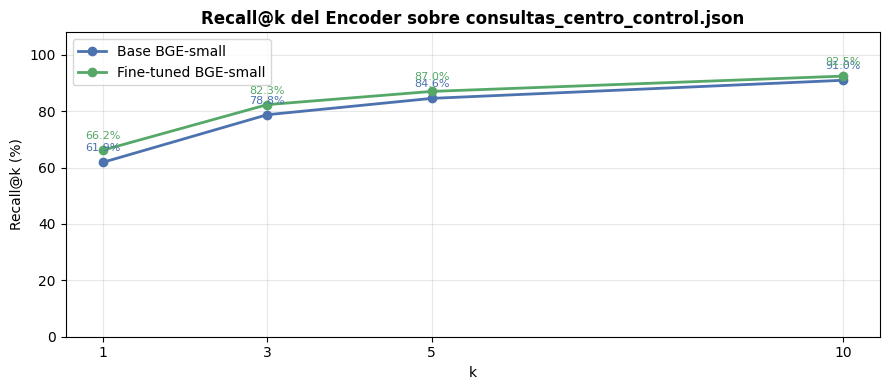

In [22]:
plot_retrieval_recall({
    'Base BGE-small': recall_base,
    'Fine-tuned BGE-small': recall_ft,
})

#### Análisis de Fallas del Encoder

Las consultas que fallan en Recall@1 son las más difíciles para el retriever.
Identificarlas ayuda a entender si el problema es semántico (query muy distinta al chunk)
o si el documento correcto tiene poco overlap léxico con la query.

In [23]:
# Consultas donde el fine-tuned encoder falla en @1 pero acierta en @3
misses_at_1 = [r for r in recall_ft['per_query'] if not r['hit@1']]
recovers_at_3 = [r for r in misses_at_1 if r.get('hit@3', False)]
hard_misses   = [r for r in misses_at_1 if not r.get('hit@3', False)]

print(f'Fallos totales @1: {len(misses_at_1)}/{recall_ft["n"]} ({len(misses_at_1)/recall_ft["n"]*100:.1f}%)')
print(f'Recuperados en @3: {len(recovers_at_3)}')
print(f'Fallos persistentes @3: {len(hard_misses)}')

print('\n— Muestra de fallos persistentes (no en top-3) —')
for r in hard_misses[:5]:
    print(f'  Query: {r["query"][:90]}')
    print(f'  Gold doc: {r["gold_doc"]}')
    print()

Fallos totales @1: 274/810 (33.8%)
Recuperados en @3: 131
Fallos persistentes @3: 143

— Muestra de fallos persistentes (no en top-3) —
  Query: According to the complete systems overview, what is the star-like module configuration of 
  Gold doc: MASA-DOC-036

  Query: Which module did Commander Santiago Reyes oversee, and what were his secondary responsibil
  Gold doc: MASA-DOC-028

  Query: What are the differences between the Colibrí module and other modules like Jaguar or Quetz
  Gold doc: MASA-DOC-004

  Query: Which module does Commander Santiago Reyes oversee during a medical emergency response?
  Gold doc: MASA-DOC-042

  Query: Who monitors the telemetry from the Colibrí's navigation systems during docking?
  Gold doc: MASA-DOC-021



## 6. Fine-tuning del Decoder (QLoRA)

Ajustamos `meta-llama/Llama-3.2-1B-Instruct` para la tarea de *tool calling* usando:

**QLoRA 4-bit NF4** (Dettmers et al. 2023):
- Cuantización 4-bit con doble cuantización → reduce huella de memoria ~4x.
- LoRA sobre todas las proyecciones de atención y MLP (`q,k,v,o,gate,up,down`).
- Rank r=16, α=32, dropout=0.05.

**ResponseOnlyCollator**:
- Identifica la frontera `<|start_header_id|>assistant<|end_header_id|>\n\n` a nivel de texto (no de tokens).
- Solo los tokens de la respuesta (la tool call) contribuyen al gradiente — el sistema no aprende a reproducir el prompt.

**System prompt dinámico**:
- Incluye TODOS los valores válidos de cada parámetro (cargados desde `tools_definition.json` + enriquecidos con `train.csv`).
- Un modelo de 1B necesita "copiar" los valores del contexto, no generarlos de memoria (Gorilla 2023, ToolACE 2024).

**Contexto de recuperación**:
- Para cada query de entrenamiento se recuperan los top-3 chunks por retrieval híbrido BM25+dense — mismo retriever que en inferencia, eliminando distributional shift.

In [24]:
# Fine-tuning de Llama-3.2-1B-Instruct con QLoRA
# Técnicas:
#   - QLoRA 4-bit NF4 (Dettmers et al. 2023)
#   - ResponseOnlyCollator con split a nivel de TEXTO — evita fallos silenciosos
#   - System prompt dinámico con TODOS los valores válidos (Gorilla 2023, ToolACE 2024)
#   - synthetic_csv: datos sintéticos balanceados generados en la sección 2.2

DECODER_DIR = 'models/decoder'

if FORCE_RECOMPUTE or not (Path(DECODER_DIR) / 'adapter_config.json').exists():
    print('Fine-tuning decoder...')
    from finetune_decoder import finetune_decoder
    finetune_decoder(
        train_csv=TRAIN_SPLIT_CSV,
        synthetic_csv=SYNTHETIC_CSV if Path(SYNTHETIC_CSV).exists() else None,
        encoder_dir=ENCODER_DIR,
        retrieval_index=RETRIEVAL_INDEX,
        tools_def_file=str(DATA_DIR / 'tools_definition.json'),
        output_dir=DECODER_DIR,
    )
else:
    print(f'Decoder fine-tuneado encontrado en {DECODER_DIR}')

Fine-tuning decoder...


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


System prompt preview (first 300 chars):
You are the AI controller for MASA's Kuntur Station space station (400 km above Earth).
Given a control center operator query and retrieved technical documentation, output EXACTLY ONE tool call.
Output ONLY the tool call string. No explanation. No other text.

CANONICAL FORMAT RULES — any violation 

Cleaning training data...
Clean train: 2313 rows (from 2313)
Merged 4064 synthetic rows → total 6377 training examples
Loading retrieval index...
Building BM25 index for hybrid retrieval...
Encoding training queries...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/100 [00:00<?, ?it/s]

...

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 11,272,192 || all params: 1,247,086,592 || trainable%: 0.9039
Fine-tuning decoder...


Step,Training Loss


KeyboardInterrupt: 

### 6.1 Curva de Pérdida del Decoder

La pérdida (cross-entropy sobre los tokens de la tool call) debe disminuir de forma estable.
Un plateau temprano puede indicar learning rate demasiado bajo; un pico puede indicar gradient overflow (cubierto por `max_grad_norm=1.0`).

In [ ]:
from utils import plot_decoder_loss
plot_decoder_loss(DECODER_DIR)

## 7. Inferencia

El pipeline de inferencia encadena cuatro pasos:
1. **Codificación de la query** con el encoder BGE (con instruction prefix).
2. **Recuperación híbrida** BM25 + dense → top-3 chunks más relevantes.
3. **Generación**: Llama-3.2-1B-Instruct con adaptadores LoRA produce la tool call en modo greedy (determinista).
4. **Canonicalización**: normaliza el output al formato exacto exigido (orden de parámetros, mayúsculas, sin comillas en enteros).

### 7.1 Carga de Modelos

### 7.1 Carga del Modelo

Cargamos el decoder fine-tuneado (Llama-3.2-1B-Instruct + LoRA adapter en 4-bit) y el encoder BGE.
La cuantización NF4 reduce el uso de memoria a ~1 GB, permitiendo inferencia en GPU de consumo.

In [ ]:
# Cargar decoder fine-tuneado con adaptadores LoRA
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

DECODER_BASE = 'meta-llama/Llama-3.2-1B-Instruct'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print('Cargando modelo base...')
base_model = AutoModelForCausalLM.from_pretrained(
    DECODER_BASE,
    quantization_config=bnb_config,
    device_map='auto',
    torch_dtype=torch.bfloat16,
)

print('Aplicando adaptadores LoRA...')
model = PeftModel.from_pretrained(base_model, DECODER_DIR)
model.eval()

tokenizer = AutoTokenizer.from_pretrained(DECODER_DIR)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = 'left'  # left-padding para batch inference

print('Modelo listo para inferencia')

In [ ]:
# Cargar encoder para inferencia
from sentence_transformers import SentenceTransformer

encoder = SentenceTransformer(ENCODER_DIR)
print('Encoder cargado')

### 7.2 Función de Predicción

`predict_tool_call(query)` implementa el pipeline completo end-to-end.
La decodificación **greedy** (`do_sample=False`) es correcta para este espacio de salida cerrado (enum values) — muestreo solo añadiría ruido.
`max_new_tokens=64` es suficiente para el tool call más largo (~30 tokens).

In [ ]:
# Pipeline completo: query → retrieval → generación → canonicalización
# El system prompt se construye dinámicamente desde tools_definition.json
# con TODOS los valores válidos de cada parámetro — crítico para exact match en 1B.

from utils import build_tools_prompt

SYSTEM_PROMPT = build_tools_prompt(tools_def)
print("System prompt generado dinámicamente:")
print(SYSTEM_PROMPT[:500])
print("...")

EOT_TOKEN_ID = tokenizer.convert_tokens_to_ids('<|eot_id|>')
if EOT_TOKEN_ID is None or EOT_TOKEN_ID == tokenizer.unk_token_id:
    EOT_TOKEN_ID = tokenizer.eos_token_id


def predict_tool_call(query: str, top_k: int = 3) -> str:
    # 1. Encode query
    q_emb = encoder.encode(
        [QUERY_PREFIX + query], normalize_embeddings=True
    )[0].astype(np.float32)

    # 2. Hybrid retrieval
    ctx_chunks = retrieve_hybrid(query, q_emb, top_k=top_k)
    context    = '\n\n---\n\n'.join(ctx_chunks)

    # 3. Format prompt (NO add_generation_prompt=False — we want the model to continue)
    user_content = f'Technical Documentation:\n{context}\n\nOperator Query: {query}'
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': user_content},
    ]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    # 4. Greedy decoding — deterministic, correct for closed enum output space
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False,
            eos_token_id=[tokenizer.eos_token_id, EOT_TOKEN_ID],
            pad_token_id=tokenizer.eos_token_id,
        )

    # 5. Decode only the new tokens (the generated tool call)
    new_ids    = output_ids[0][inputs['input_ids'].shape[1]:]
    raw_output = tokenizer.decode(new_ids, skip_special_tokens=True).strip()

    # 6. Canonicalize — enforces parameter order, lowercase, protocol_id uppercase, etc.
    return canonicalize(raw_output, tools_def)


# Prueba con el ejemplo del enunciado
test_query = 'Oxygen levels in Jaguar dropped to 18.2% over the last hour and pressure is falling. What protocol should we activate?'
result = predict_tool_call(test_query)
print(f'\nQuery:     {test_query}')
print(f'Predicción: {result}')

### 7.3 Evaluación en Conjunto de Validación

Evaluamos en `df_val` (10% de los datos limpios, nunca visto durante el fine-tuning del decoder).
La métrica es **exact string match** — igual que en Kaggle — sin crédito parcial.
El análisis de errores por herramienta identifica qué clases el modelo confunde más.

In [ ]:
# Validación en conjunto de validación
from tqdm import tqdm

val_preds = []
for _, row in tqdm(df_val.iterrows(), total=len(df_val), desc='Validando'):
    pred = predict_tool_call(row['query'])
    val_preds.append(pred)

val_accuracy = sum(p == g for p, g in zip(val_preds, df_val['tool_call'])) / len(df_val)
print(f'\nVal Accuracy (exact match): {val_accuracy:.4f} ({val_accuracy*100:.2f}%)')

# Análisis de errores
errors = [(q, p, g) for q, p, g in zip(df_val['query'], val_preds, df_val['tool_call']) if p != g]
print(f'Errores: {len(errors)}/{len(df_val)}')
for q, p, g in errors[:3]:
    print(f'  Q: {q[:80]}')
    print(f'  PRED: {p}')
    print(f'  GOLD: {g}')
    print()

#### Accuracy por Herramienta

Las barras rojas indican herramientas con accuracy < 70%.
El número entre paréntesis es el tamaño de la muestra de validación para esa clase.

In [ ]:
from utils import plot_val_accuracy
plot_val_accuracy(val_preds, df_val['tool_call'].tolist())

## 8. Generación del Archivo de Respuesta

Ejecutamos el pipeline completo sobre las 766 queries de `test.csv` y guardamos el resultado en `result/submission.csv`.
El formato debe coincidir exactamente con `sample_submission.csv`: columnas `id` y `tool_call`.

In [ ]:
# Inferencia sobre test.csv y generación de submission.csv
from tqdm import tqdm

print(f'Generando predicciones para {len(test_df)} consultas de test...')

test_preds = []
for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Inferencia'):
    pred = predict_tool_call(row['query'])
    test_preds.append(pred)

# Construir submission
submission = pd.DataFrame({
    'id':        test_df['id'],
    'tool_call': test_preds,
})

RESULT_DIR = Path('result')
RESULT_DIR.mkdir(exist_ok=True)
SUBMISSION_PATH = RESULT_DIR / 'submission.csv'
submission.to_csv(SUBMISSION_PATH, index=False)
print(f'submission.csv guardado en {SUBMISSION_PATH}')
print(submission.head(10).to_string(index=False))

In [ ]:
# Verificación final del submission
sub = pd.read_csv(SUBMISSION_PATH)

print(f'Filas: {len(sub)} (esperado: {len(test_df)})')
print(f'Columnas: {list(sub.columns)} (esperado: [id, tool_call])')
print(f'Valores nulos: {sub.isnull().sum().sum()}')

pred_tools = sub['tool_call'].str.extract(r'^(\w+)')[0]
print('\nDistribución de predicciones:')
print(pred_tools.value_counts().to_string())

from utils import validate_tool_call
sample = sub['tool_call'].sample(20, random_state=0)
valid_count = sum(validate_tool_call(tc, tools_def) for tc in sample)
print(f'\nFormato canónico válido (muestra 20): {valid_count}/20')